In [ ]:
##################################################################
# # ! Moon Topographic-Potential Computation: Spherical Harmonics
##################################################################
# %% 
# # ! Setup
import numpy as np
import pyshtools as pysh
import pygmt
import xarray as xr
import time
from datetime import datetime

In [ ]:
# # ! Start time
print("=" * 80)
print(f"Start time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

Start time: [2026-05-15 08:55:37]


In [ ]:
# # ! Constants
myG = 6.67430e-11
G = pysh.constants.G.value
gm_moon = pysh.constants.Moon.gm.value
r_calc = 1748000.0

In [ ]:
# # ! Shape of Moon
#### * Shape
lmax_shp = 359
clm_shp_moon = pysh.SHCoeffs.from_file(f'input/Moon_shape_719.sh', 
                                       lmax=lmax_shp, 
                                       name='LOLA_shape (Moon)',
                                       units='m', format='bshc')
r_itfc = clm_shp_moon.coeffs[0,0,0]

In [ ]:
# # ! Computation of topographic potential: Spectral-domain 
rho0 = 2560.0 # kg/m^3
max_nmax = 7
NMAXs = np.arange(1, max_nmax+1)
clms = []
print('*'*32+'\n' + 'Computation of Topographic Potential: Spectral-domain\n' + '*'*32)
for nmax in NMAXs:
    t0 = time.time()
    lmax = (lmax_shp+1)*nmax-1
    clm_tgp_moon = \
        pysh.SHGravCoeffs.from_shape(shape=clm_shp_moon,
                                     rho=rho0,
                                     gm=gm_moon,
                                     nmax=nmax,
                                     lmax=lmax,
                                     lmax_grid=lmax,
                                     lmax_calc=lmax_shp,
                                     name=f'LOLA_Topo_Grav (Moon) nmax={nmax}')
    tc = time.time() - t0
    clms.append(clm_tgp_moon)
    print(f"nmax = {nmax:2d}; lmax = {lmax:4d}; time cost: {tc:8.2f} sec")

********************************
Computation of Topographic Potential: Spectral-domain
********************************
nmax =  1; lmax =  359; time cost:     0.61 sec
nmax =  2; lmax =  719; time cost:     1.67 sec
nmax =  3; lmax = 1079; time cost:     5.58 sec
nmax =  4; lmax = 1439; time cost:    20.10 sec
nmax =  5; lmax = 1799; time cost:    42.75 sec
nmax =  6; lmax = 2159; time cost:    88.93 sec
nmax =  7; lmax = 2519; time cost:   157.38 sec


In [ ]:
# # ! Single contribution of each nmax in a band range
print('*'*32+'\n' + 'Single Contribution of Each nmax in a Band Range\n' + '*'*32)
print(f"nmax | l-beg | l-end | t-expand |"
      f"       min_gz |       max_gz |       mean_gz|       std_gz |")
for i_clm in np.arange(len(clms)):
    nmax = NMAXs[i_clm]
    if i_clm == 0:
        dif_clm = clms[i_clm]
    else:
        lmax = (lmax_shp+1)*(nmax-1)-1
        clm_1 = clms[i_clm-1]
        clm_2 = clms[i_clm]
        dif_clm = clm_2.copy()
        dif_clm.coeffs[:,:lmax+1,:lmax+1] = \
            clm_2.coeffs[:,:lmax+1,:lmax+1] - clm_1.coeffs
    for n_cut in np.arange(nmax):
        lmax1 = (lmax_shp+1)*n_cut-1
        lmax2 = (lmax_shp+1)*(n_cut+1)-1
        dif_clm.coeffs[:, :lmax1+1, :lmax1+1] = 0.0
        dif_clm.coeffs[:, lmax2+1:, lmax2+1:] = 0.0
        t0 = time.time()
        grd_sc = dif_clm.expand(a=r_calc, 
                                f=0.0,
                                lmax_calc=lmax2)
        t1 = time.time() - t0
        gz = -1.e5 * grd_sc.rad
        min_gz  = np.min(gz.data)
        max_gz  = np.max(gz.data)
        mean_gz = np.mean(gz.data)
        std_gz  = np.std(gz.data)
        fmt = ("{:4d} | {:5d} | {:5d} | {:8.2f} | "
               "{:12.2e} | {:12.2e} | {:12.2e} | {:12.2e} |")
        print(fmt.format(nmax, lmax1+1, lmax2, t1,
                         min_gz, max_gz, mean_gz, std_gz))

********************************
Single Contribution of Each nmax in a Band Range
********************************
nmax | l-beg | l-end | t-expand |       min_gz |       max_gz |       mean_gz|       std_gz |
   1 |     0 |   359 |     0.93 |    -7.66e+02 |     1.02e+03 |    -3.56e+01 |     2.46e+02 |
   2 |     0 |   359 |     1.01 |    -5.97e+01 |     9.92e+01 |     5.31e-01 |     6.80e+00 |
   2 |   360 |   719 |     2.06 |    -4.28e+00 |     5.61e+00 |    -2.00e-04 |     4.15e-01 |
   3 |     0 |   359 |     2.18 |    -4.18e+01 |     3.39e+01 |     8.83e-04 |     1.17e+00 |
   3 |   360 |   719 |     3.27 |    -5.50e+00 |     6.62e+00 |    -2.14e-04 |     1.99e-01 |
   3 |   720 |  1079 |     6.89 |    -5.35e-02 |     4.37e-02 |     3.01e-07 |     2.33e-03 |
   4 |     0 |   359 |     3.18 |    -1.85e+01 |     1.21e+01 |    -5.87e-05 |     2.65e-01 |
   4 |   360 |   719 |     4.59 |    -4.46e+00 |     5.04e+00 |     4.57e-05 |     9.56e-02 |
   4 |   720 |  1079 |     9.50 |    -1

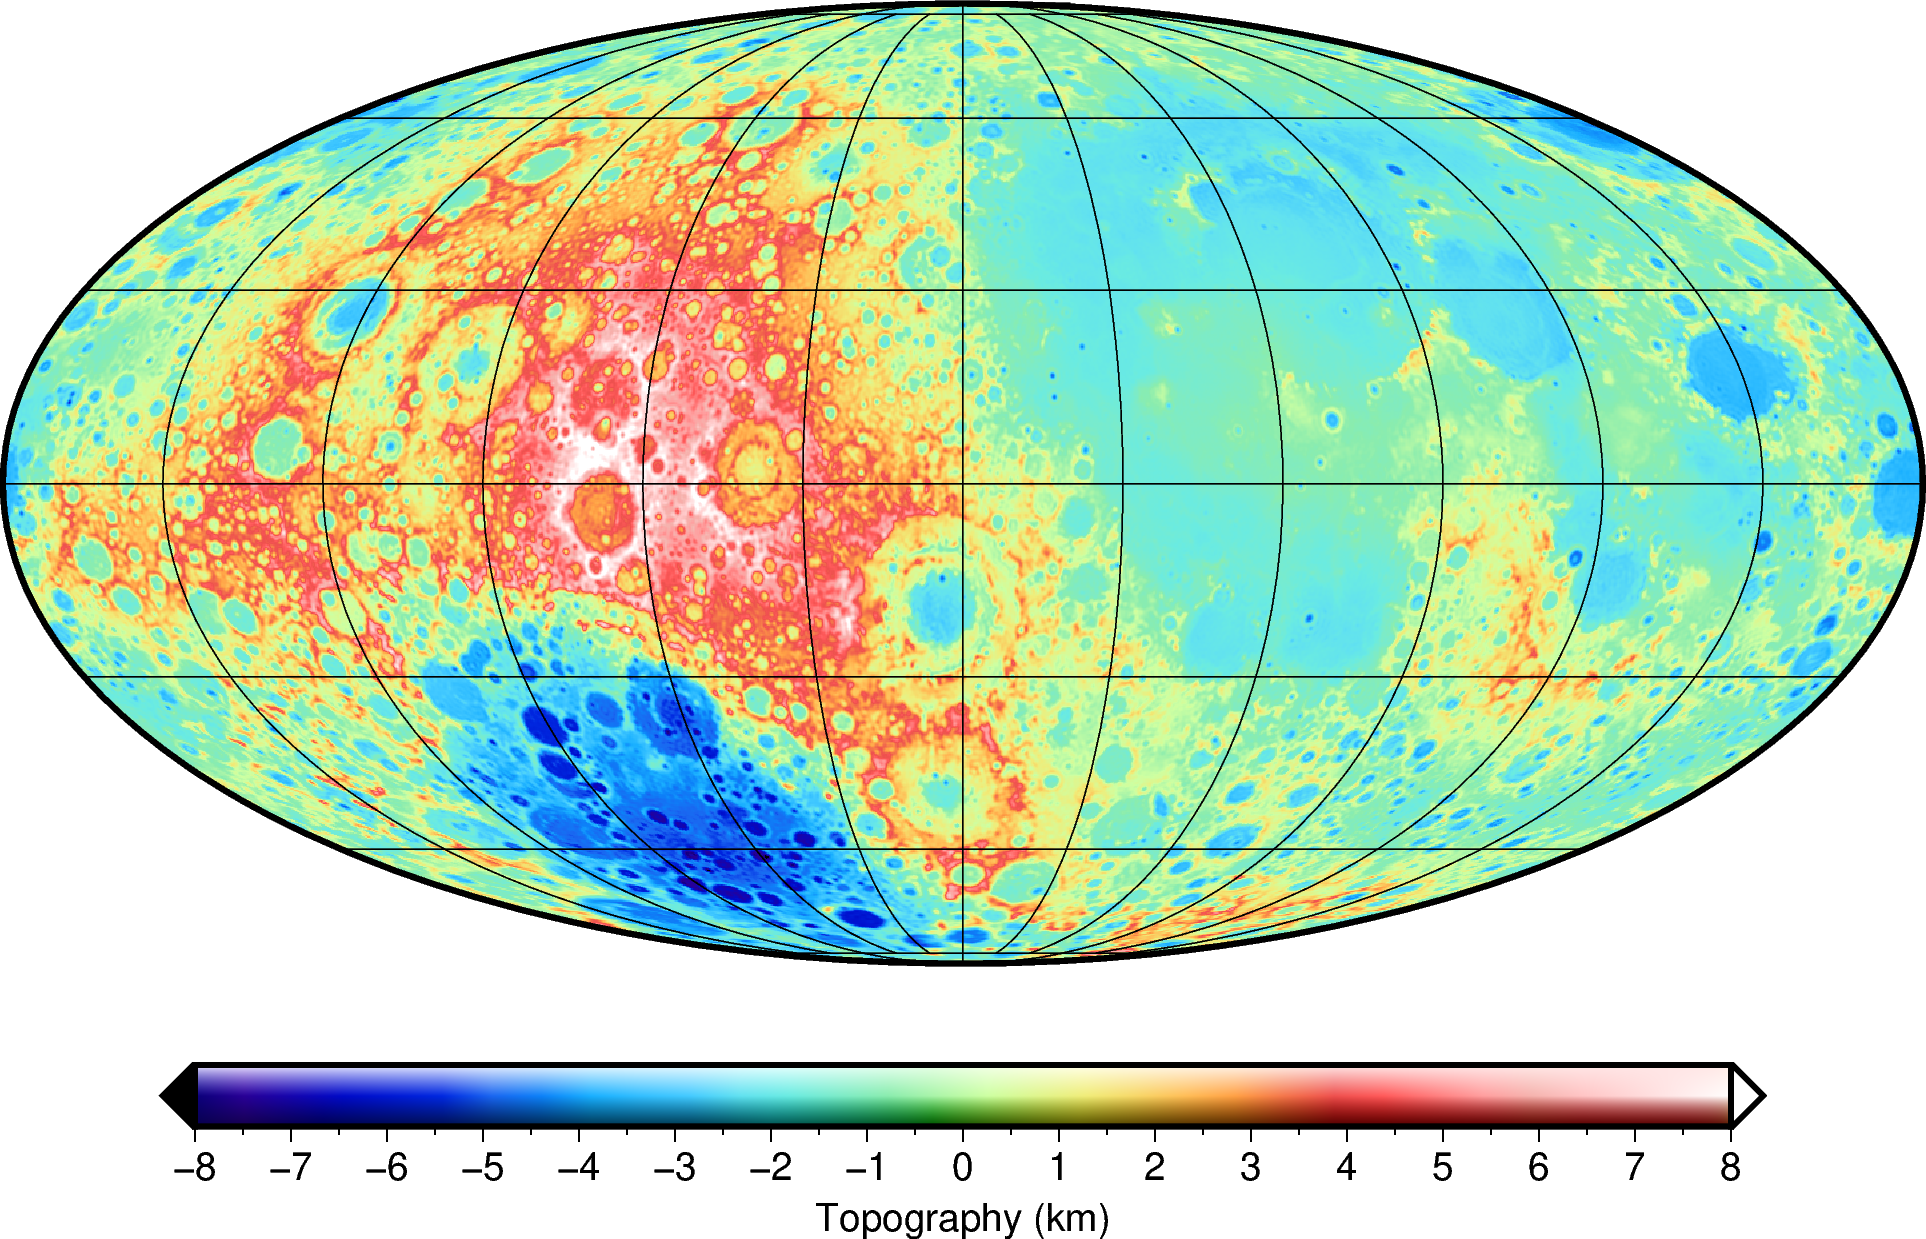

In [ ]:
# # ! Topography
grd_shp_moon = clm_shp_moon.expand()
grd_topo_moon = (grd_shp_moon - r_itfc) / 1.e3
fig = pygmt.Figure()
grd_topo_moon.plotgmt(fig=fig,
                      projection='mollweide',
                      central_longitude=-90.,
                      grid=[30, 30],
                      tick_interval=None,
                      cmap='haxby',
                      cmap_limits=[-8, 8],
                      colorbar='bottom',
                      cb_triangles='both',
                      cb_label="Topography (km)",
                      cb_tick_interval=1,
                      cb_minor_tick_interval=0.5,
                      shading=False)
# fig.savefig('Moon_Topo_GMT.png', dpi=400)
fig.show(width=800)

Topographic Gravitational Potential: gx
 min:    -490.0186 mGal
 max:     933.7645 mGal 
mean:      10.3944 mGal
 std:     154.5221 mGal
Topographic Gravitational Potential: gy
 min:    -554.0423 mGal
 max:     606.6182 mGal 
mean:       0.0028 mGal
 std:     150.4100 mGal
Topographic Gravitational Potential: gz
 min:    -722.2848 mGal
 max:    1189.7327 mGal 
mean:     -35.0236 mGal
 std:     246.6098 mGal


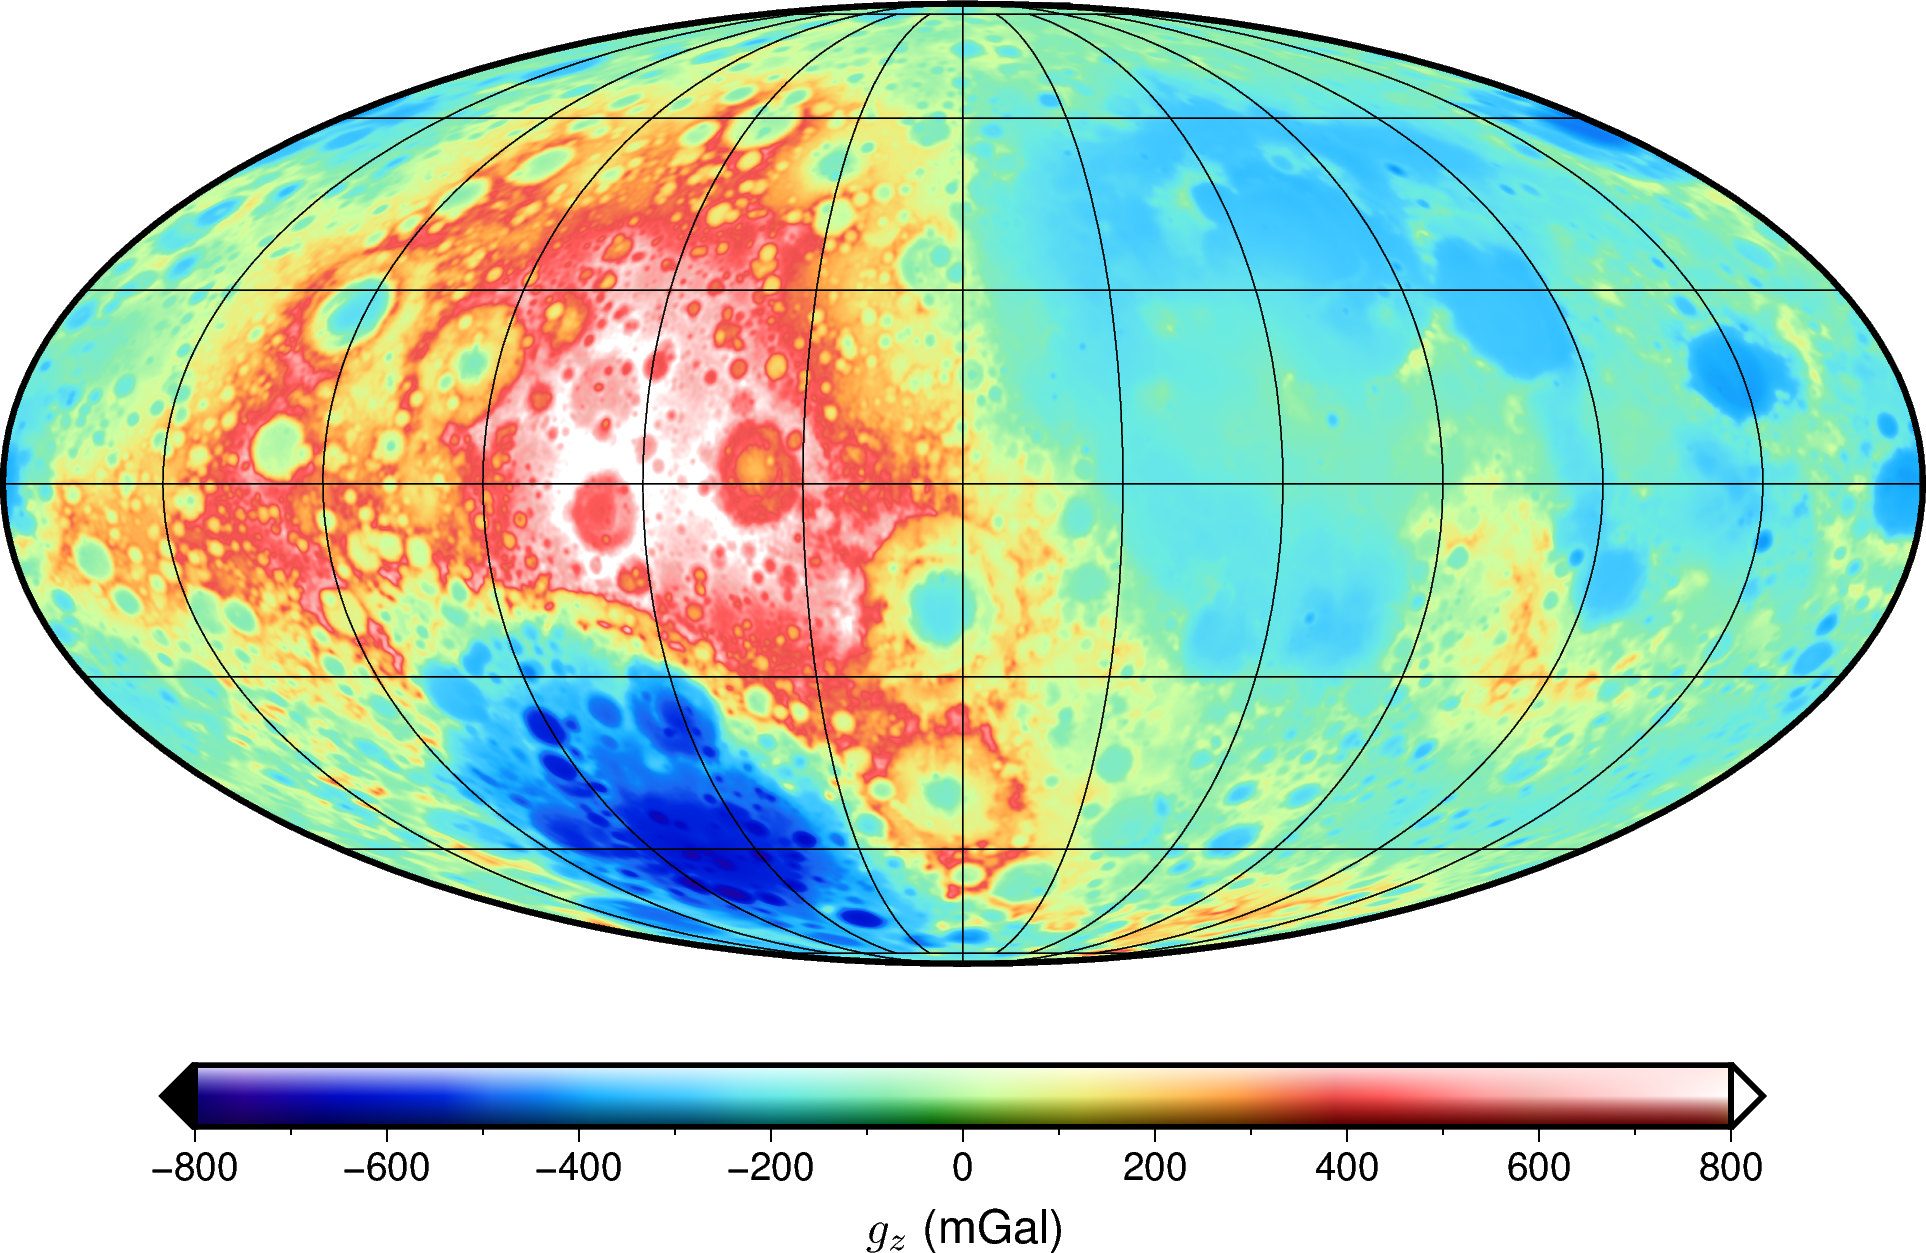

In [ ]:
# # ! Topographic potential
clm_tgp_moon = clms[-1]
grd_tgp_moon = clm_tgp_moon.expand(a=r_calc, f=0.0)
gx_tgp_moon = -1.e5 * grd_tgp_moon.theta
gy_tgp_moon =  1.e5 * grd_tgp_moon.phi
gz_tgp_moon = -1.e5 * grd_tgp_moon.rad
arr_gx, arr_gy, arr_gz = gx_tgp_moon.data, gy_tgp_moon.data, gz_tgp_moon.data
vars = ['gx', 'gy', 'gz']
for var, arr in zip(vars, [arr_gx, arr_gy, arr_gz]):
    print(f"Topographic Gravitational Potential: {var}")
    print(f" min: {np.min(arr):12.4f} mGal\n max: {np.max(arr):12.4f} mGal \n"
          f"mean: {np.mean(arr):12.4f} mGal\n std: {np.std(arr):12.4f} mGal")
fig = pygmt.Figure()
gz_tgp_moon.plotgmt(fig=fig,
                    projection='mollweide',
                    central_longitude=-90.,
                    grid=[30, 30],
                    tick_interval=None,
                    cmap='haxby',
                    cmap_limits=[-800, 800],
                    colorbar='bottom',
                    cb_triangles='both',
                    cb_label=r"@[ g_z @[ (mGal)",
                    axes_labelsize=12,
                    cb_tick_interval=200,
                    cb_minor_tick_interval=100,
                    shading=False)
# fig.savefig('Moon_TopoGz_GMT.png', dpi=400)
fig.show(width=800)

In [ ]:
# # ! Save gx, gy, gz to NetCDF
lat = gz_tgp_moon.lats()
lon = gz_tgp_moon.lons()
data_vars = {
    'gx': (('latitude', 'longitude'), arr_gx),
    'gy': (('latitude', 'longitude'), arr_gy),
    'gz': (('latitude', 'longitude'), arr_gz)}

ds = xr.Dataset(
    data_vars=data_vars,
    coords={'longitude': lon, 'latitude': lat},
    attrs={'description': 'Topographic gravity vector components of the Moon',
           'input shape model': f'LOLA_shape (Moon) with lmax={lmax_shp}',
           'nmax': max_nmax,
           'r_calc_m': r_calc,
           'ref_radius_m': r_itfc, 
           'rho_kg_m3': rho0, 
           'units': 'mGal'})
nc_file = f'moon_topo_gravity_Lshp{lmax_shp}_nmax{max_nmax}.nc'
ds.to_netcdf(nc_file)
print(f"Saved to '{nc_file}'")  

Saved to 'moon_topo_gravity_Lshp359_nmax7.nc'


In [ ]:
# # ! End time
print("=" * 80)
print(f"End time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

End time: [2026-05-15 09:11:17]
